Reversible logic e Circuits

### Reversible Logic & Circuits | Quantum Computing using Python

https://www.youtube.com/watch?v=CoFcrOny2Ag&list=PLhI5X1mNN8giEspGNb39R1d7ik6RlSI7l&index=6

In [1]:
# ambiente salvo

import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/qiskitenv/bin/python


In [2]:
import sys # versão do python
print(sys.version)

3.13.11 | packaged by Anaconda, Inc. | (main, Dec 10 2025, 21:28:48) [GCC 14.3.0]


True table

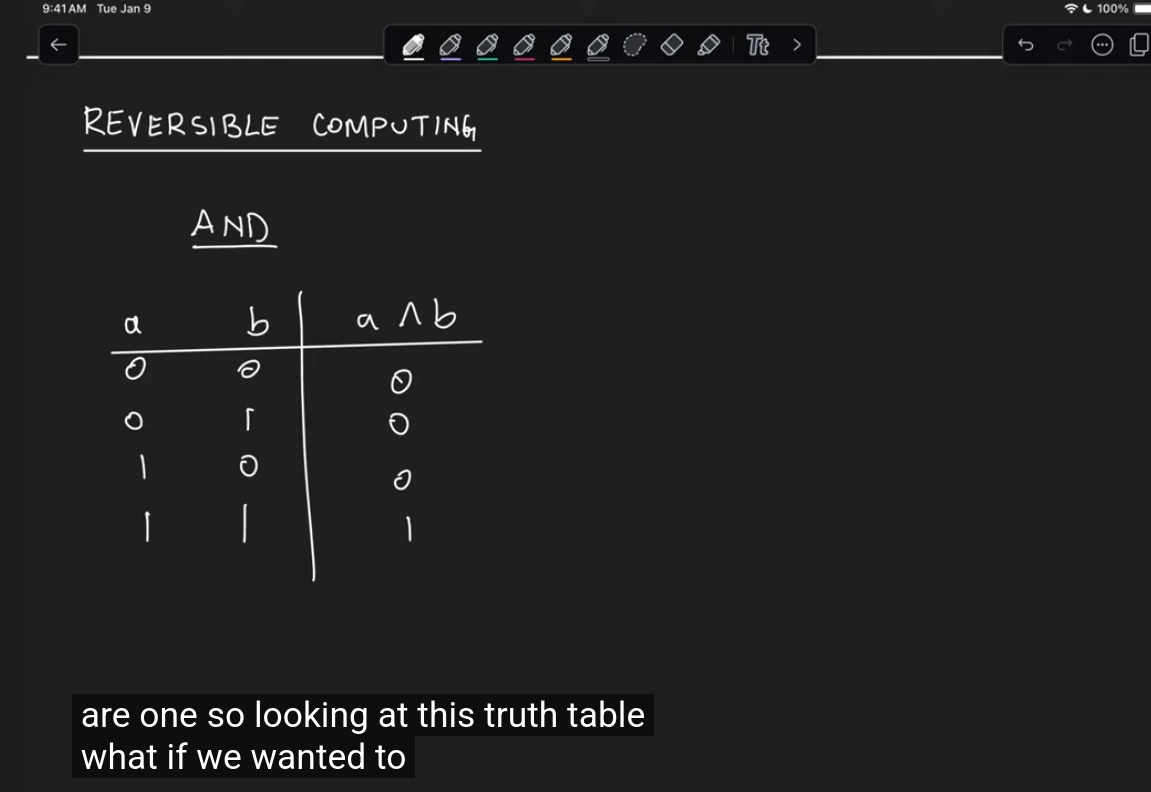


$P \land Q$ só é verdadeiro se tanto P quanto Q forem verdadeiros.


P Q P∧Q (E)

V V V

V F F

F V F

F F F

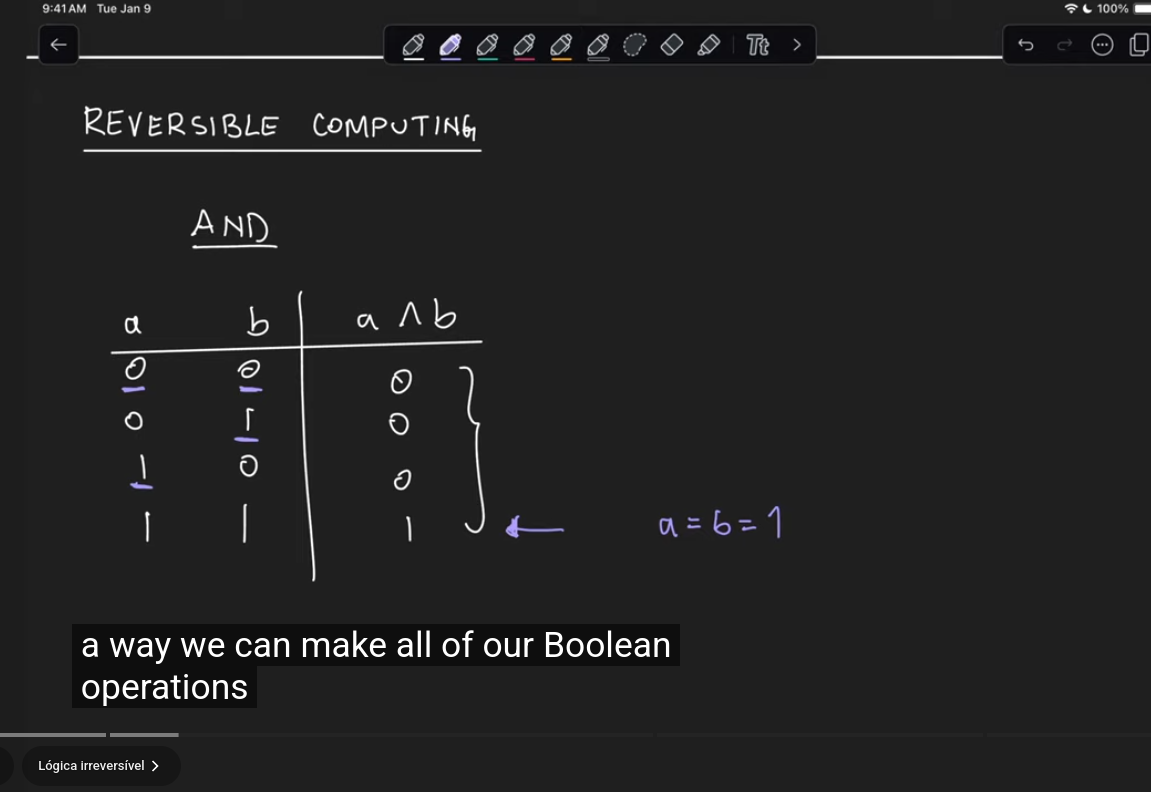

simbolo assimétrico

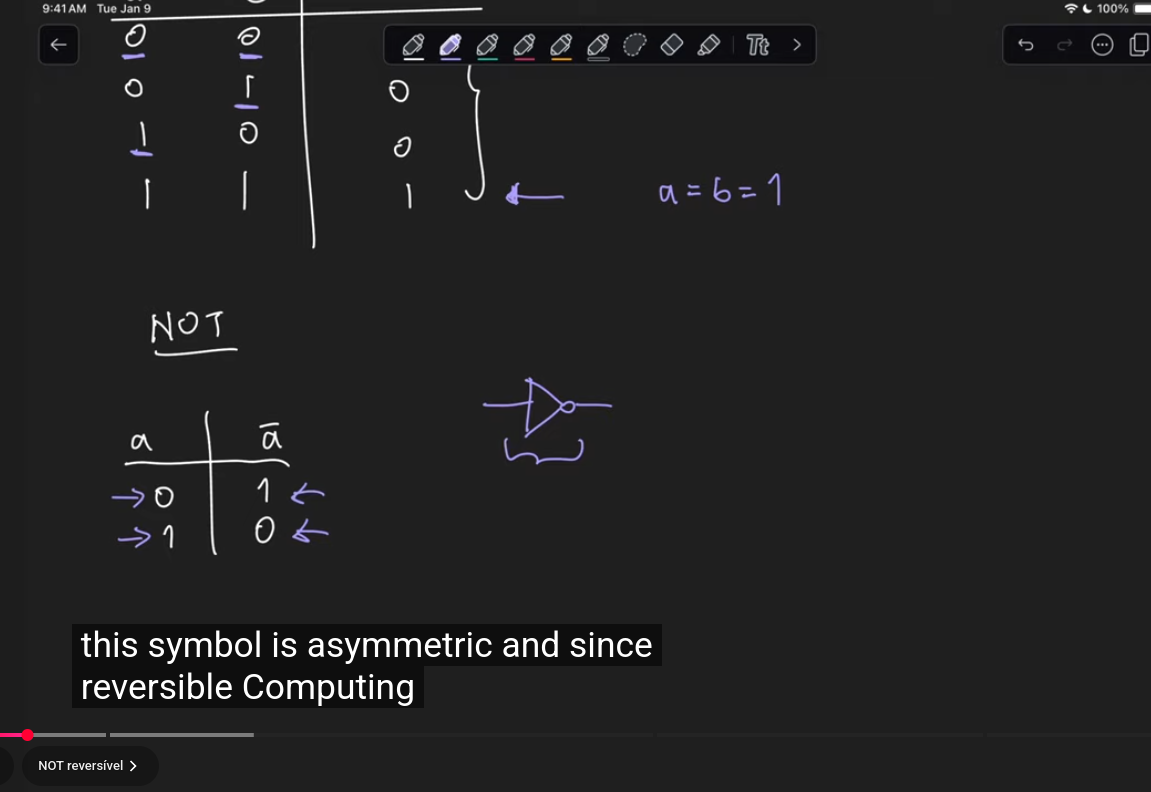

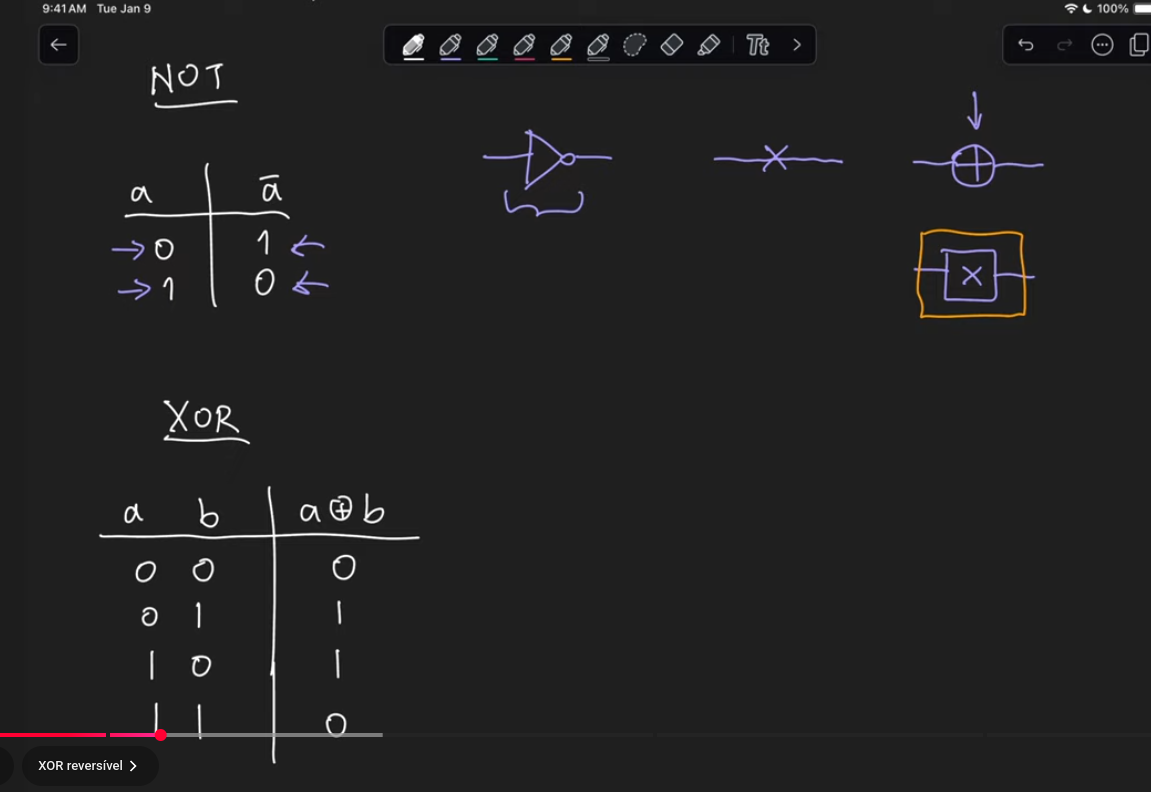

anterior 
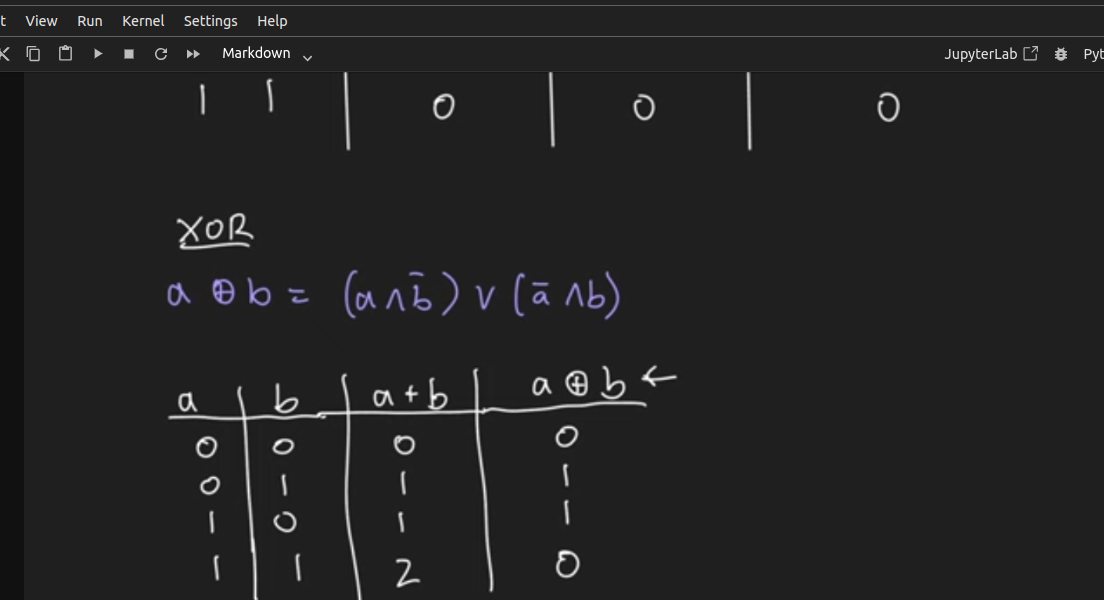

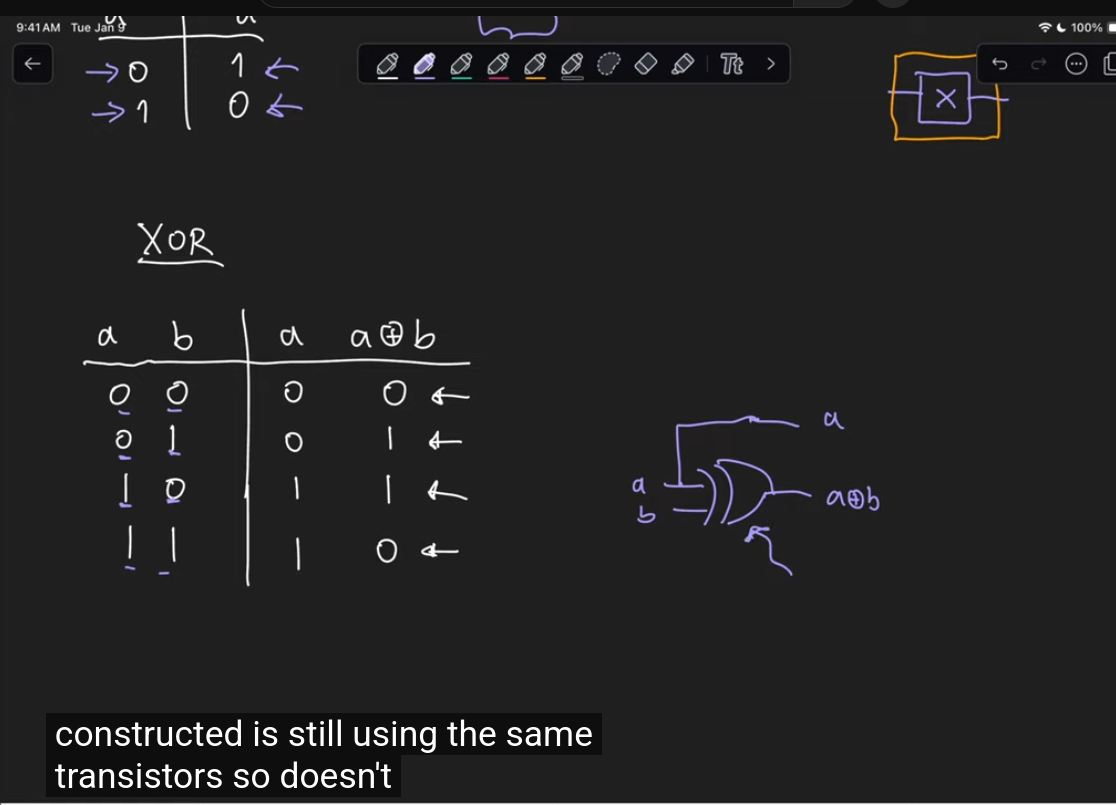

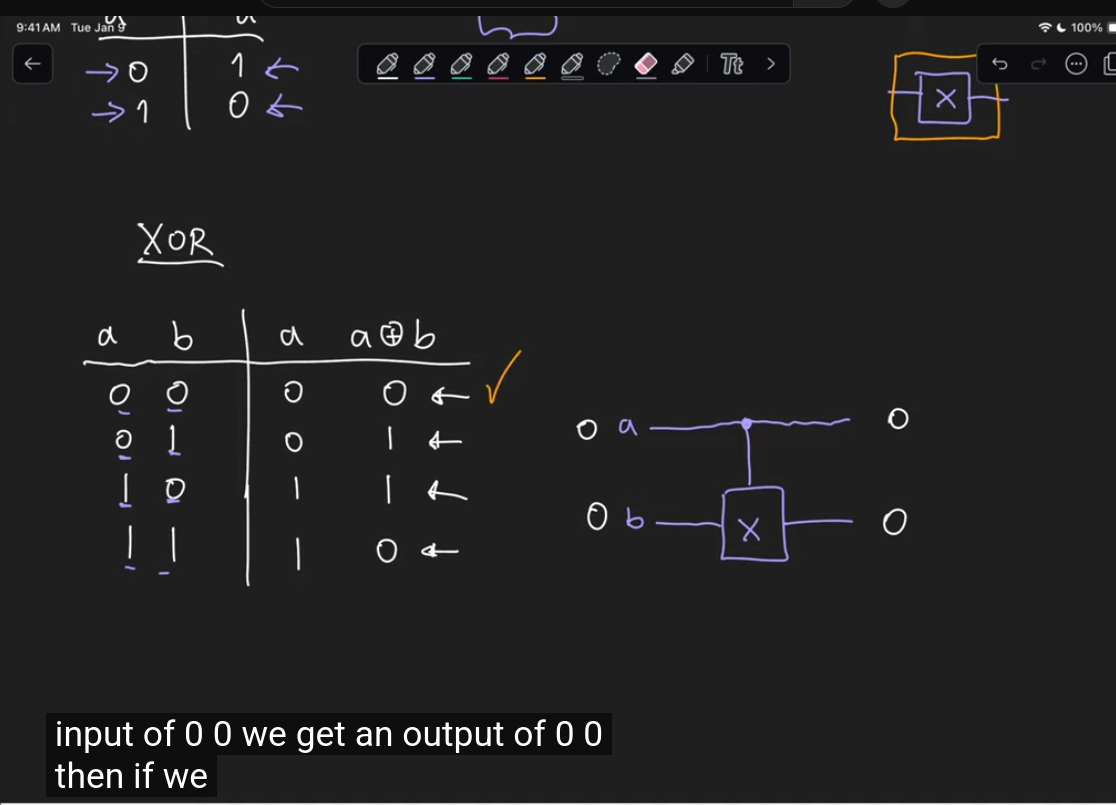

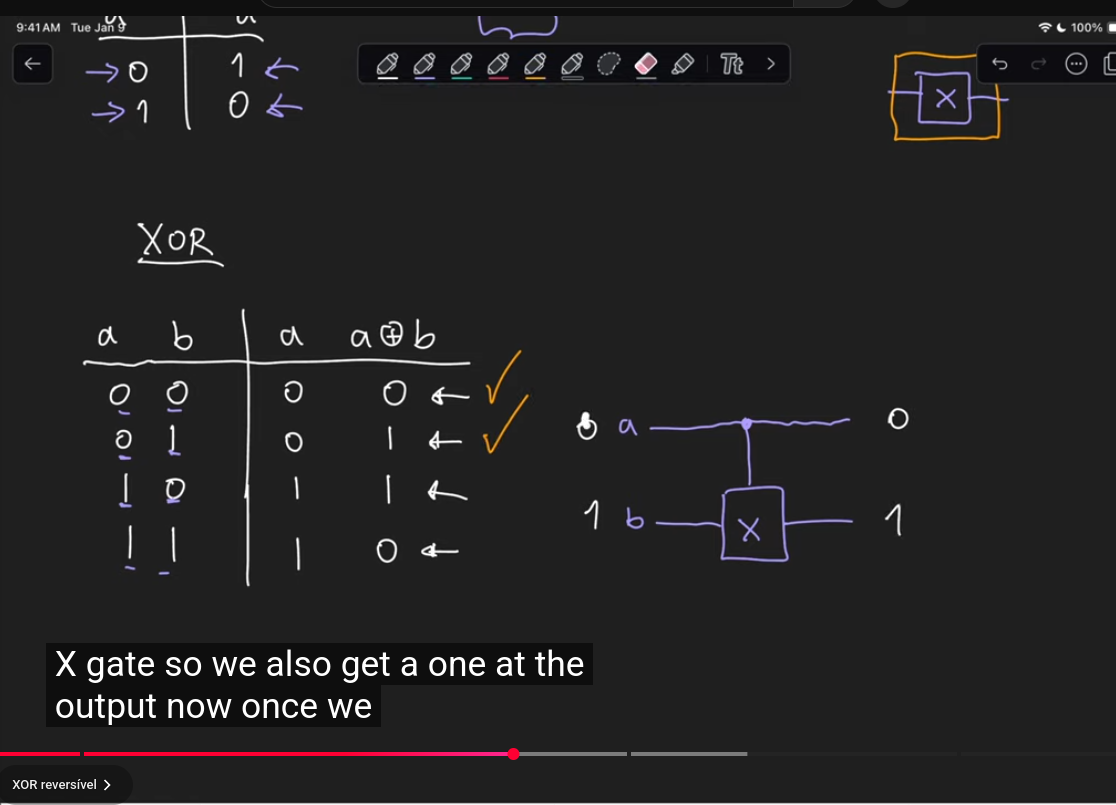

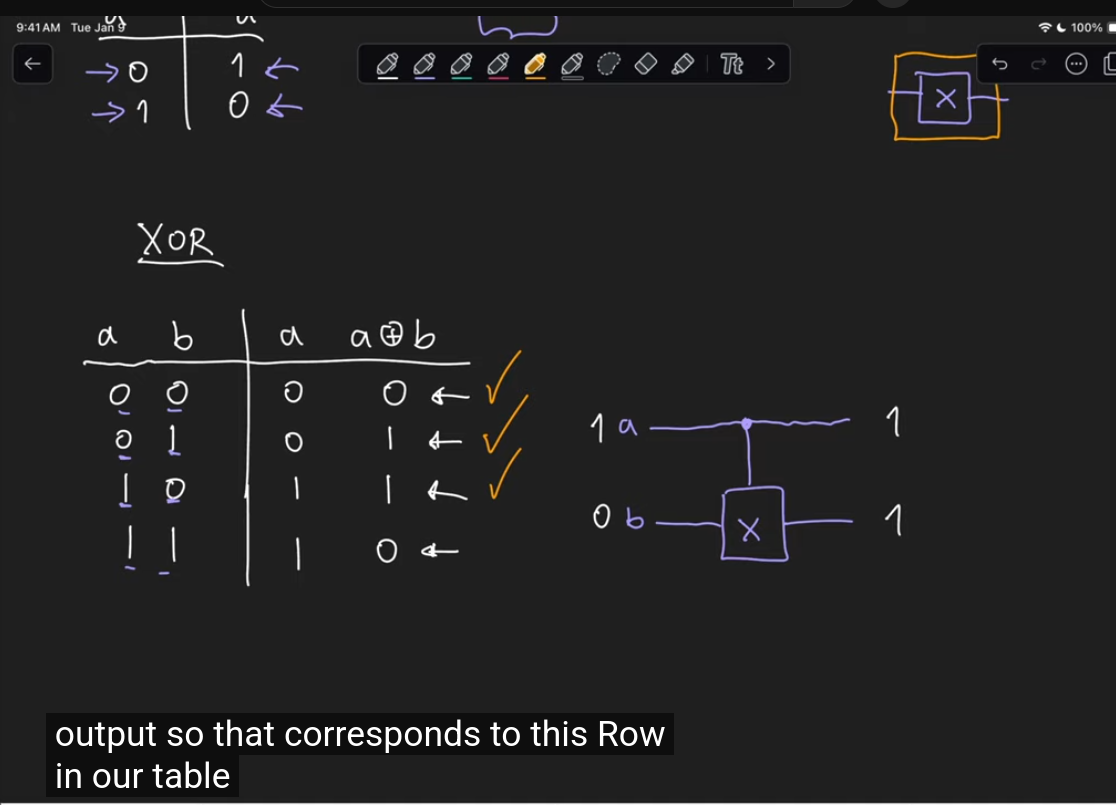

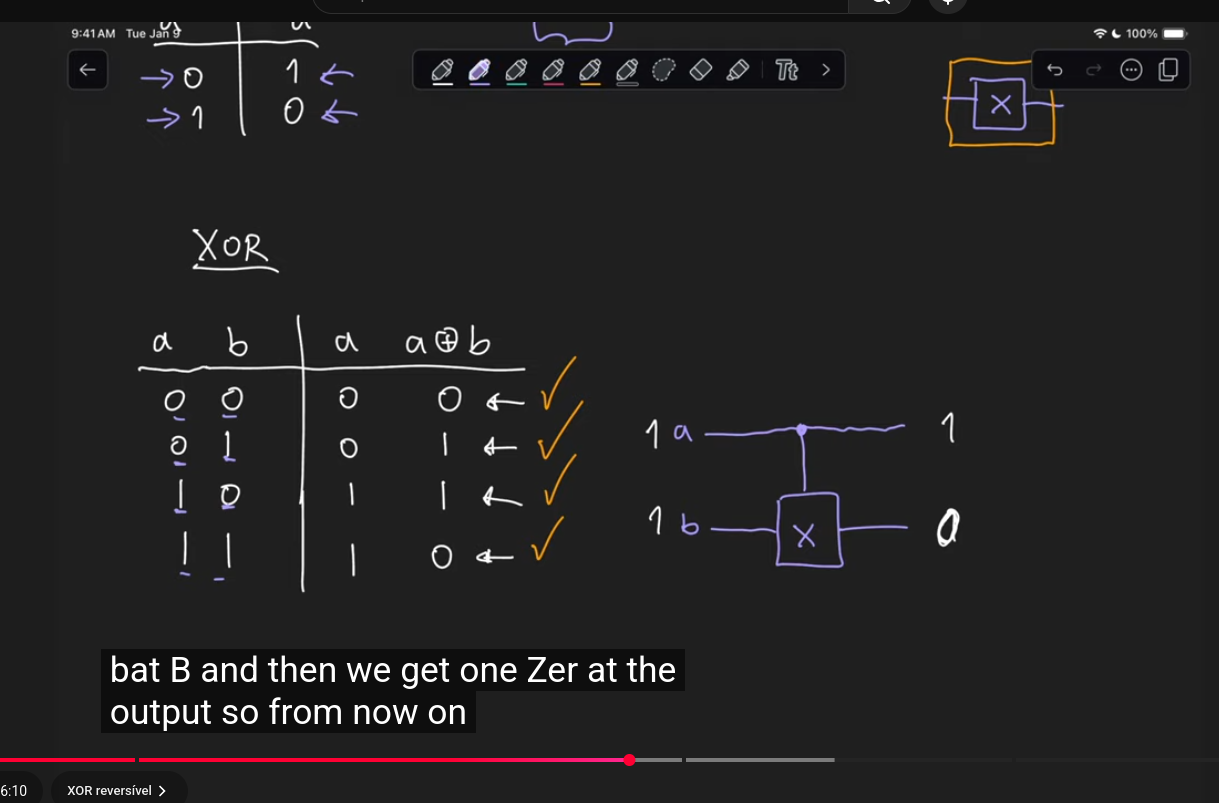

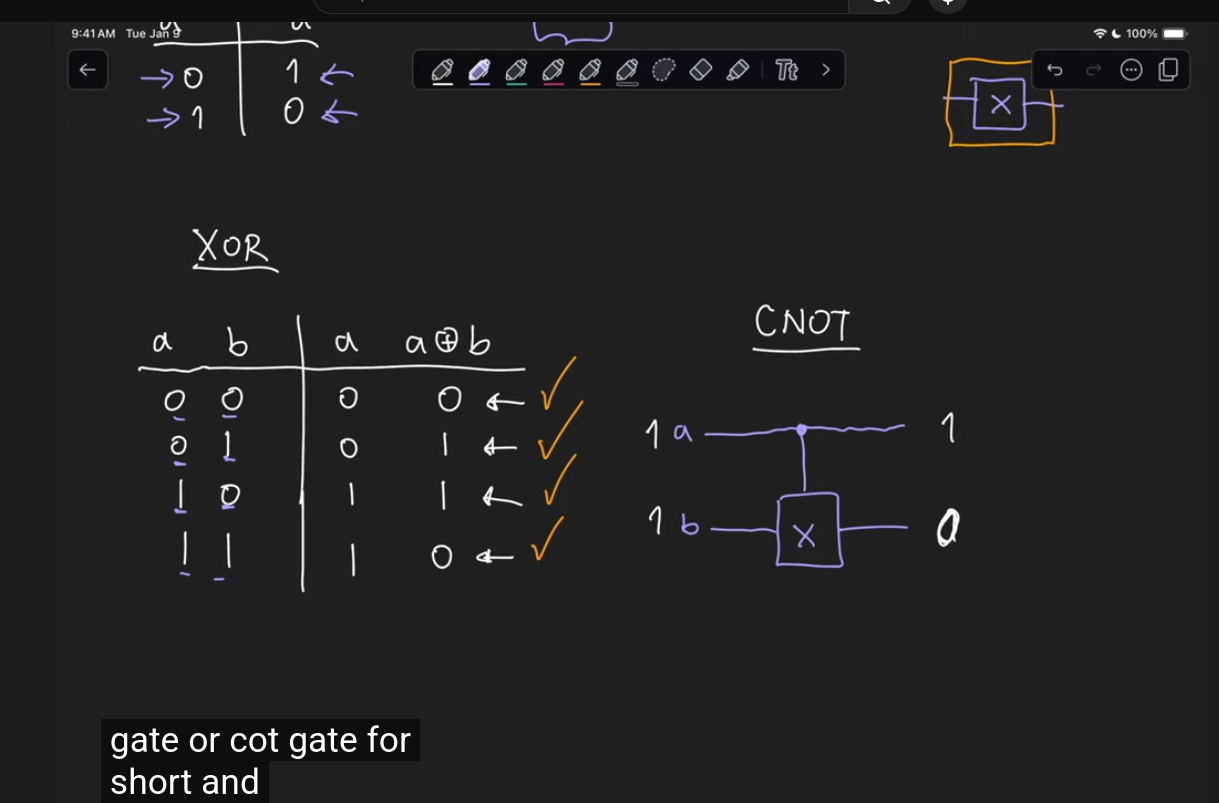

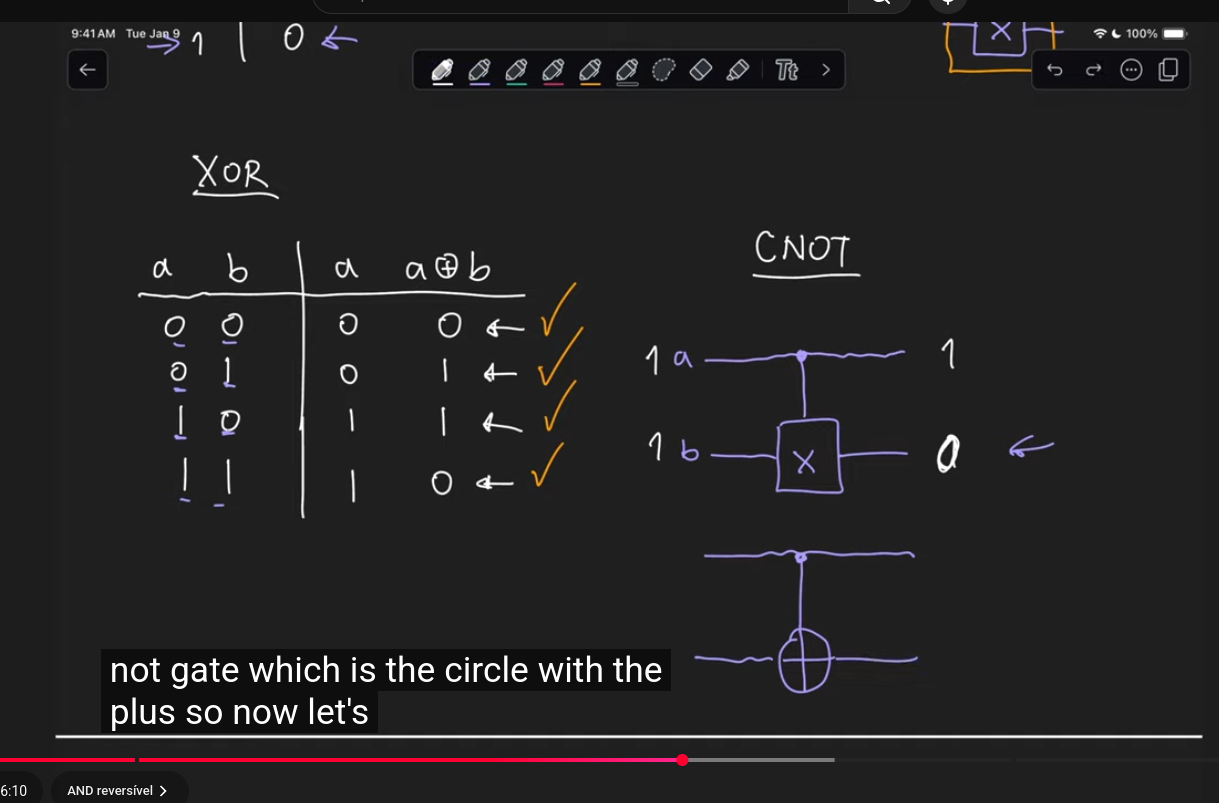

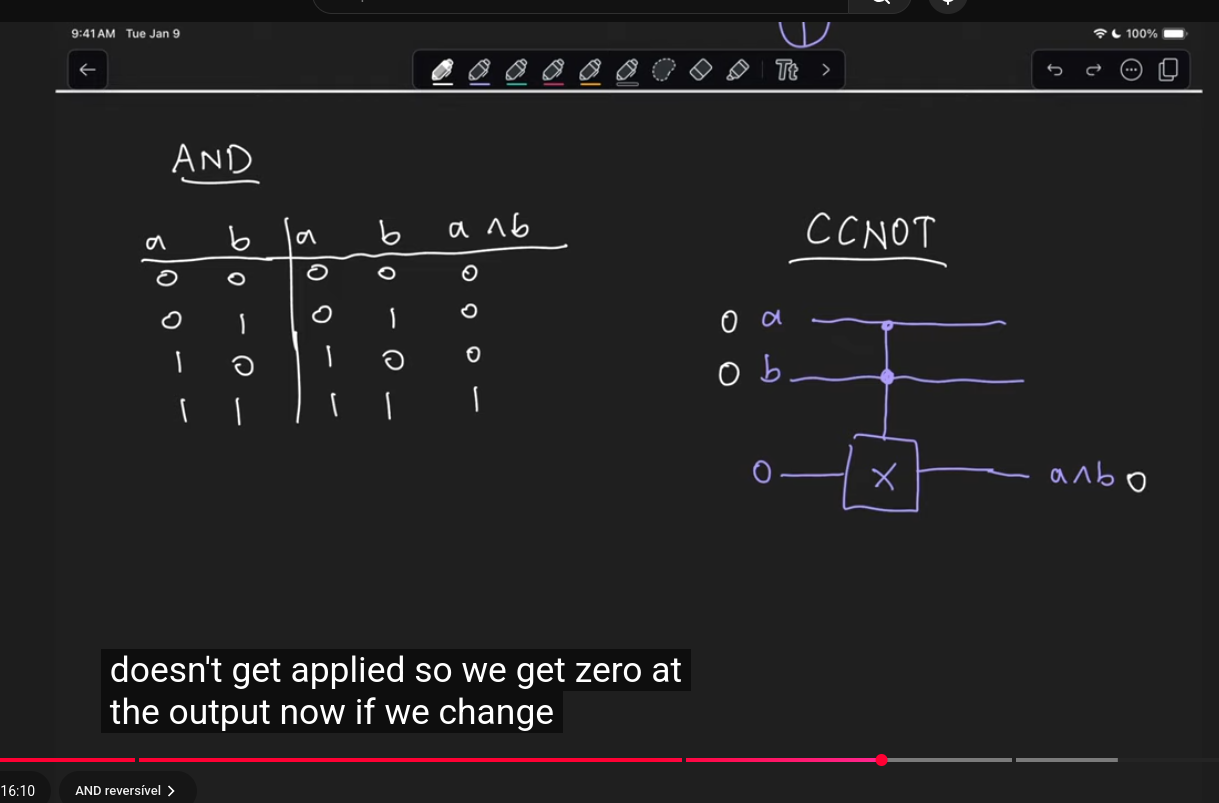

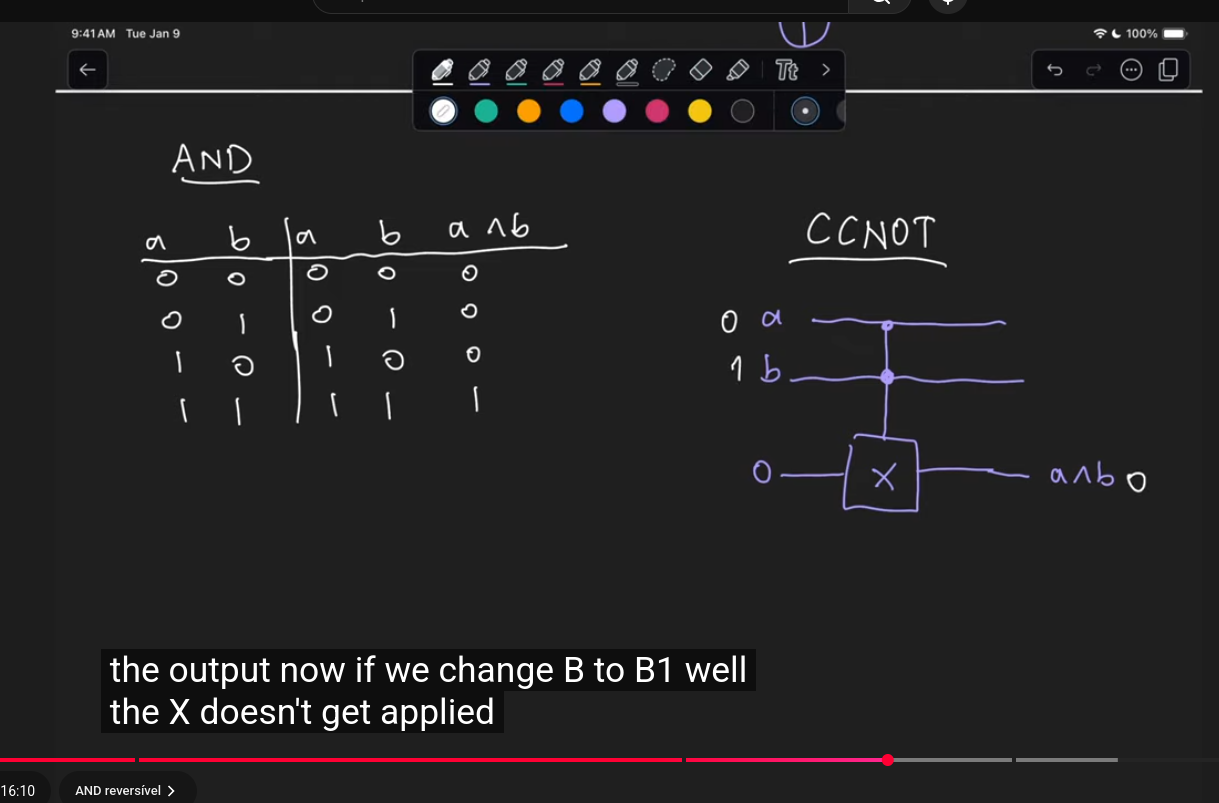

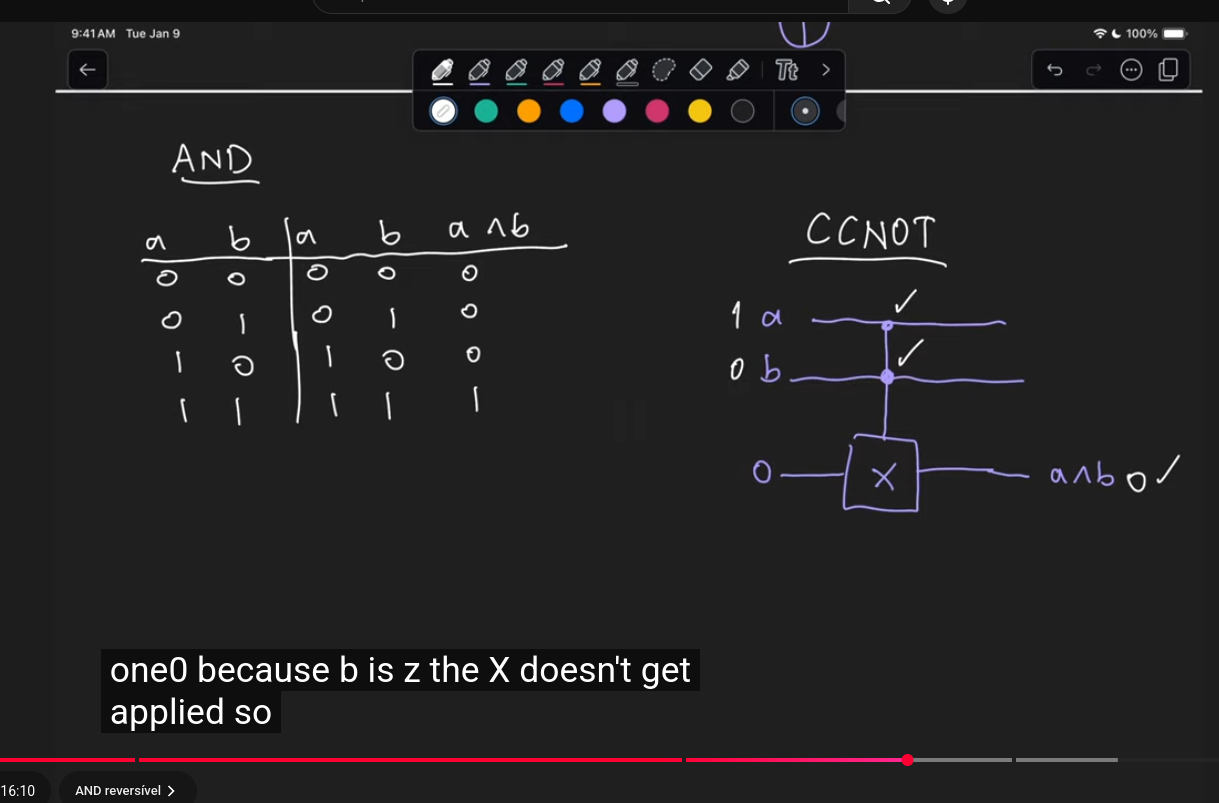

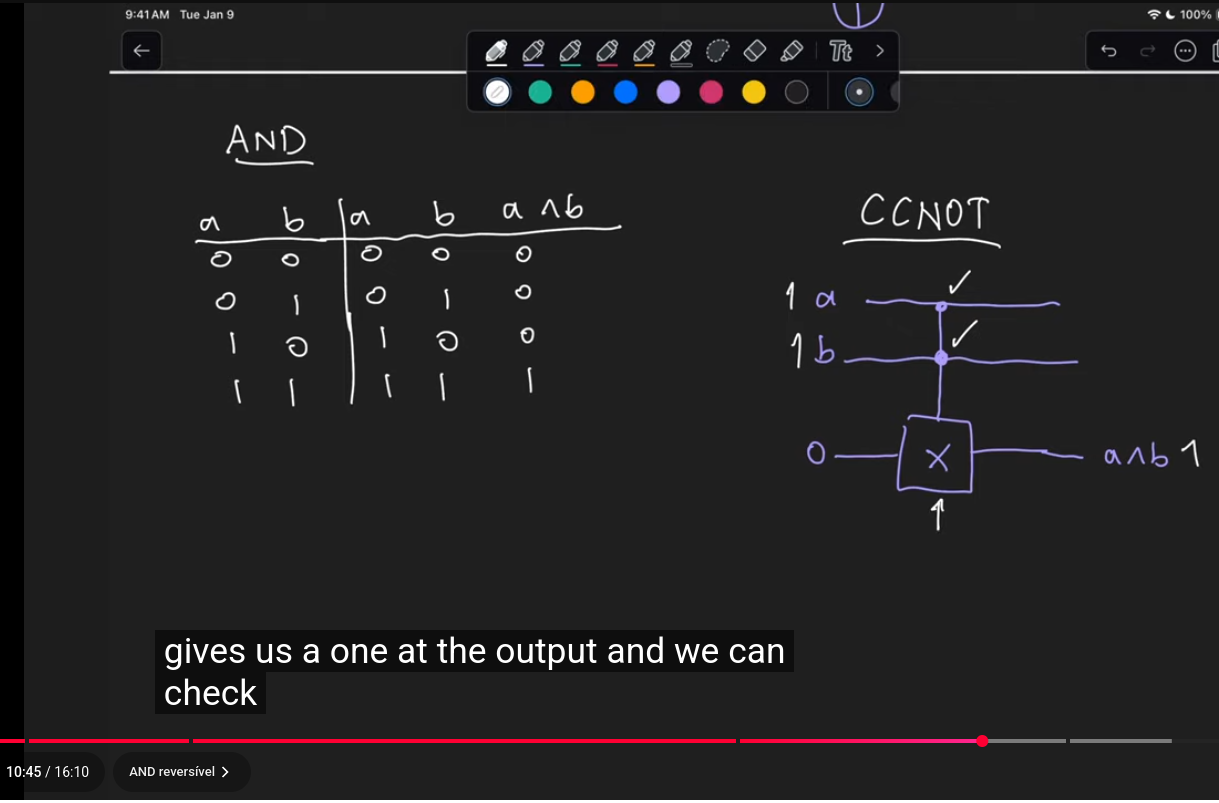

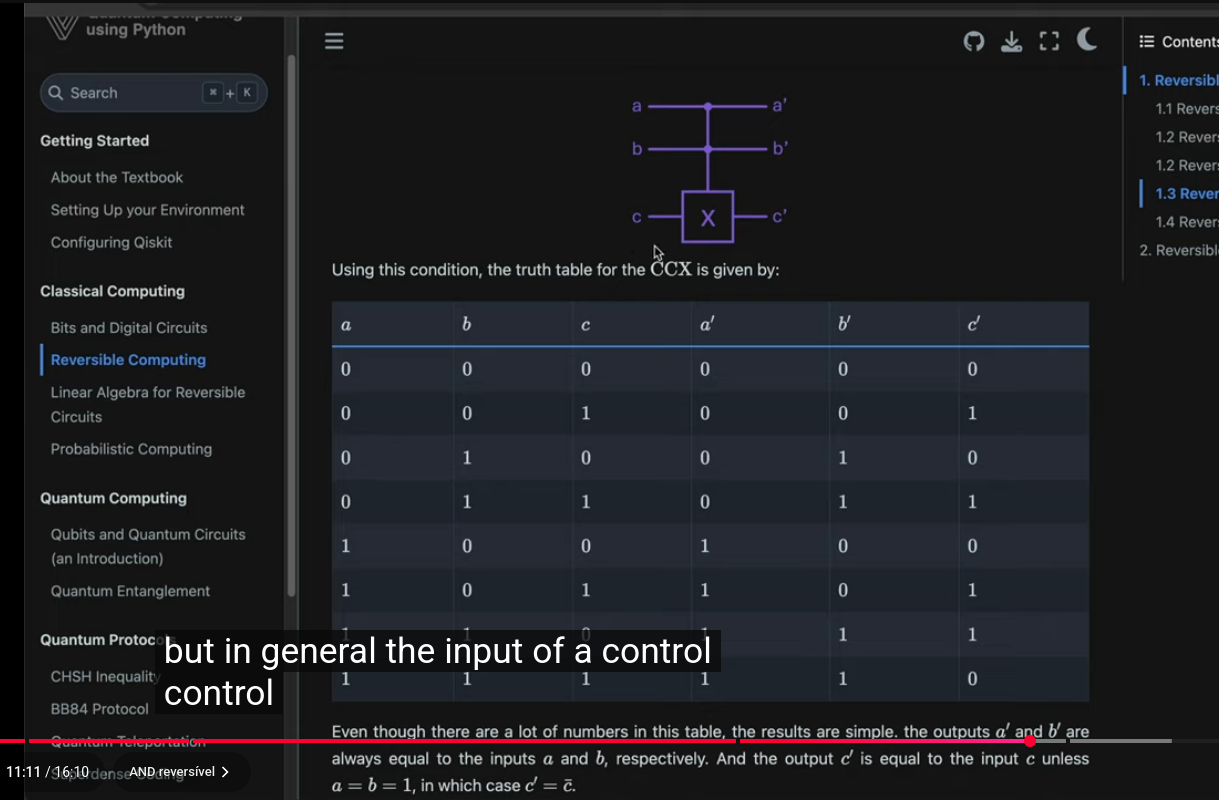

https://learnquantum.io/chapters/01_classical_computing/01_02_reversible_computing.html


O $P \lor Q$ funciona como uma escolha aberta. Ele só é falso se os dois forem falsos. Se pelo menos um for verdade, tudo é verdade.

P Q P∨Q (OU)

V V V

V F V

F V V

F F F

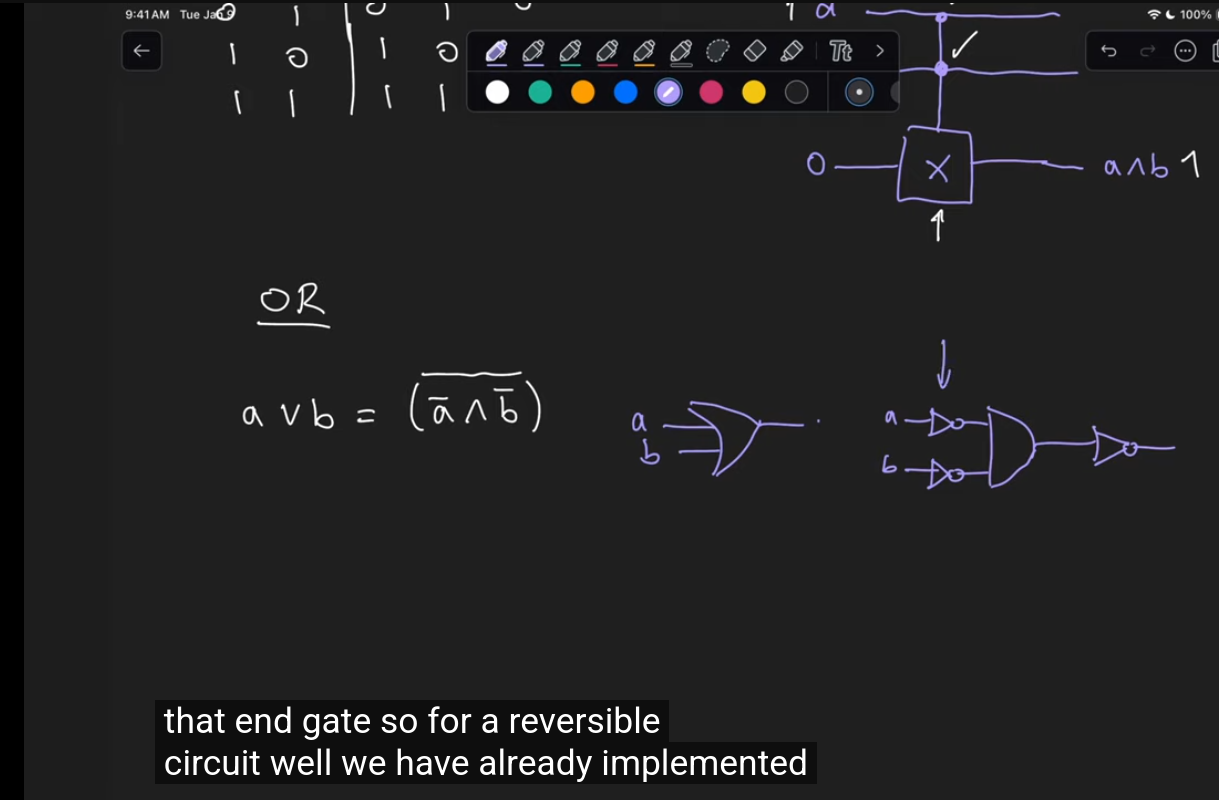

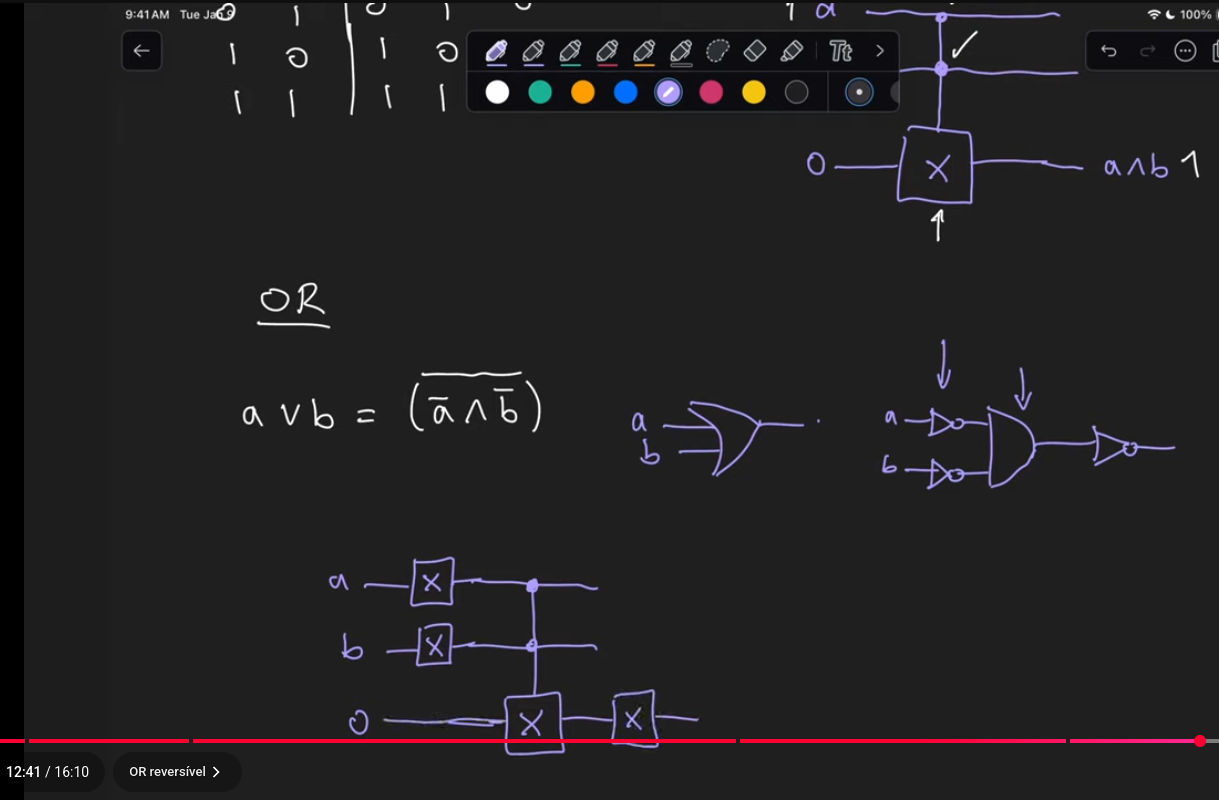

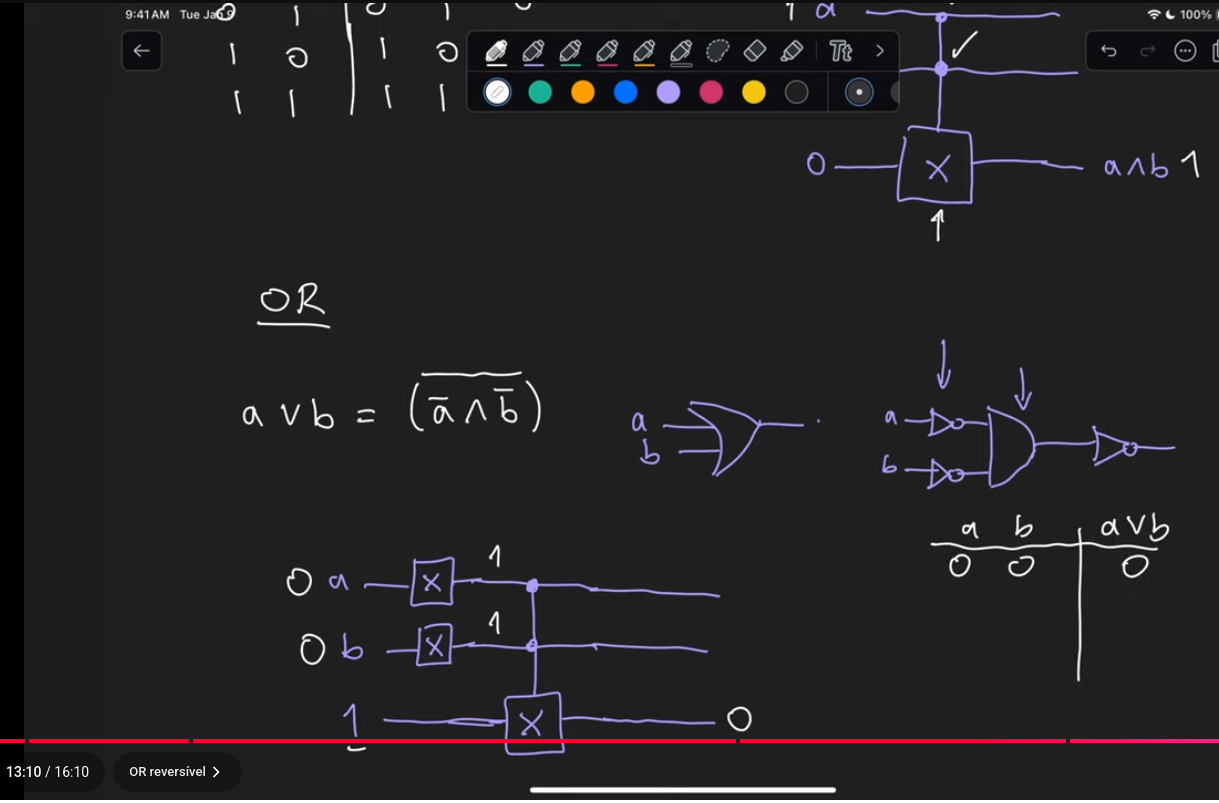

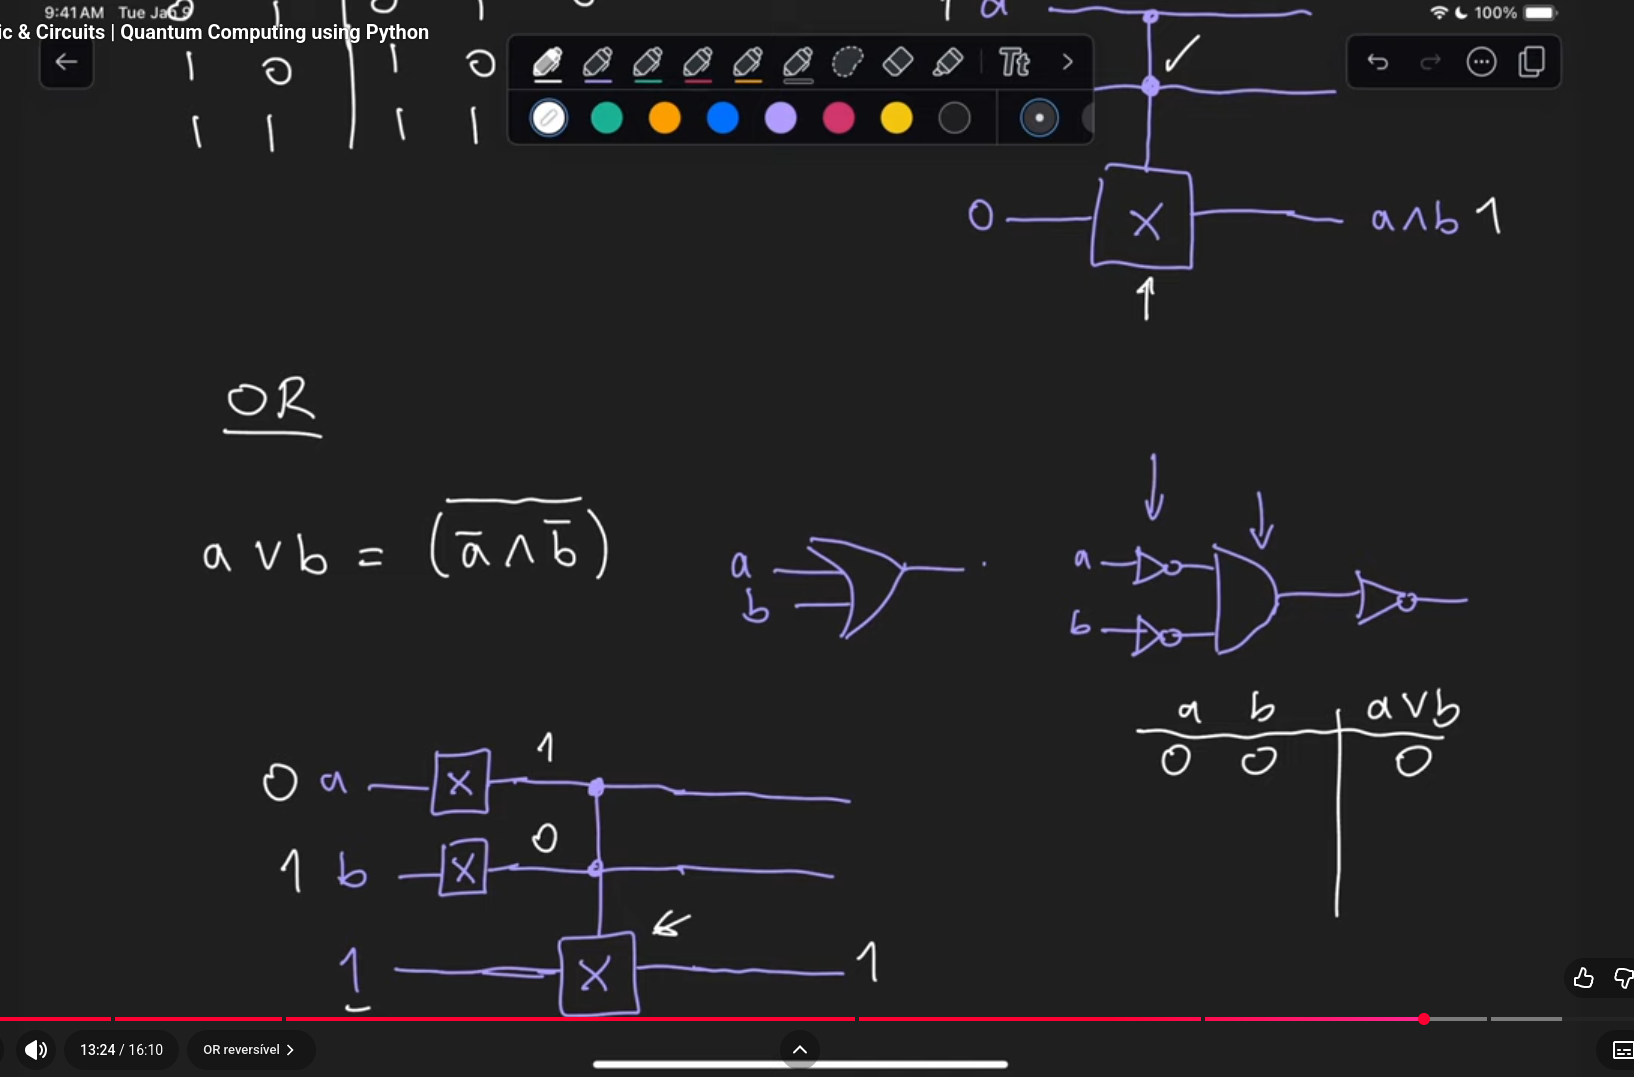

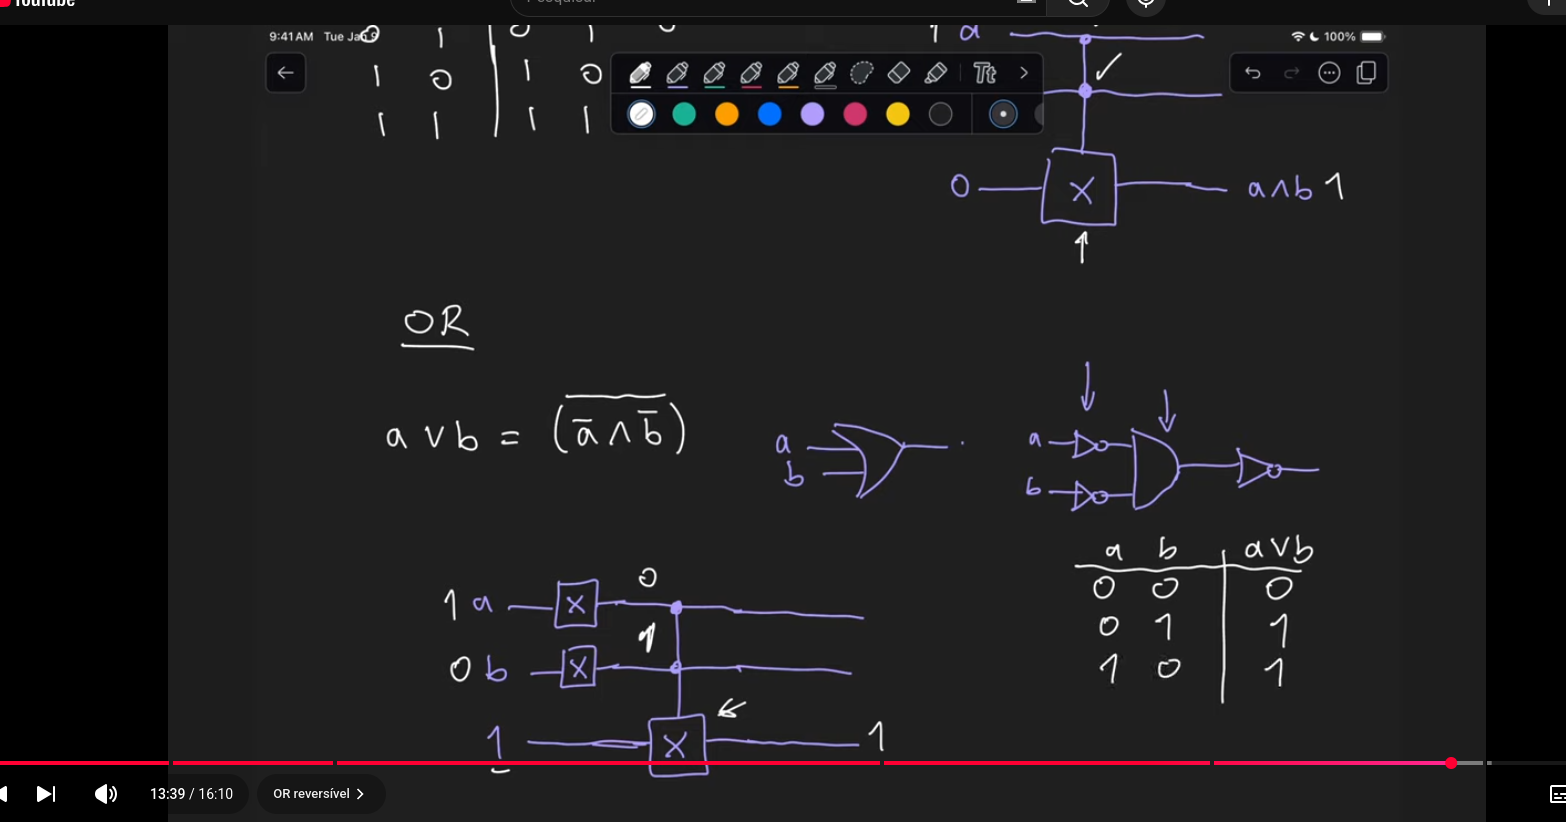

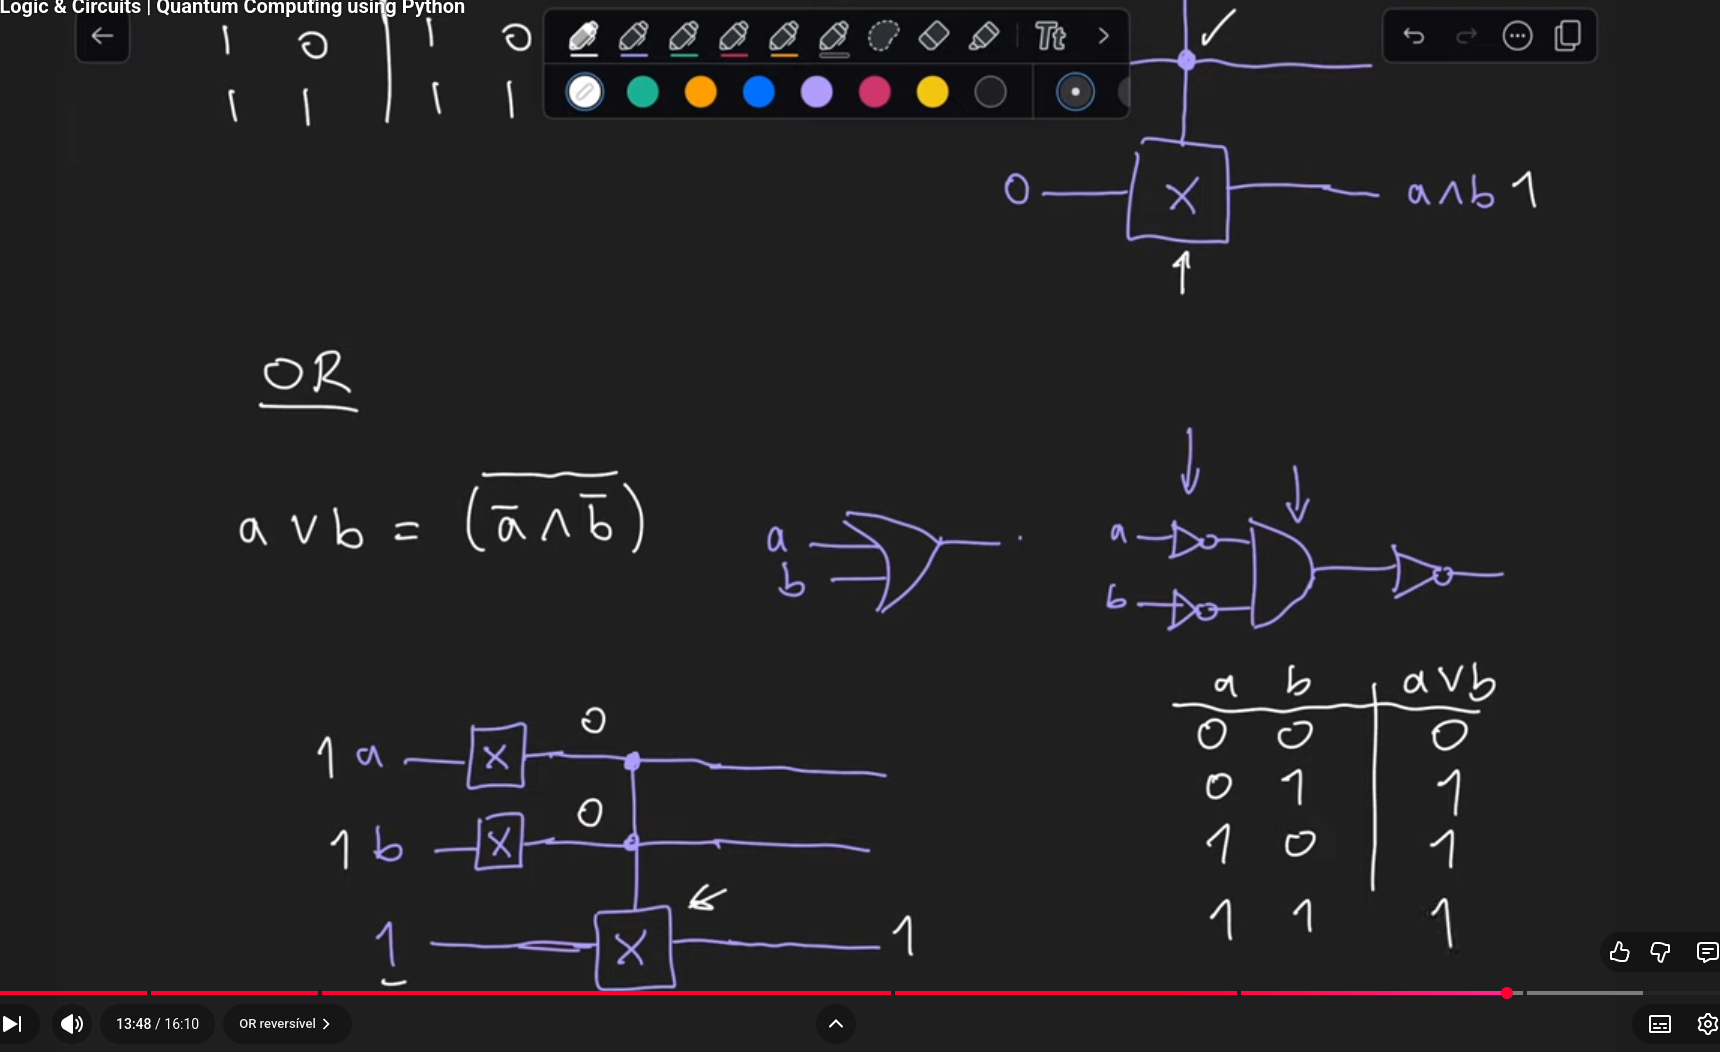

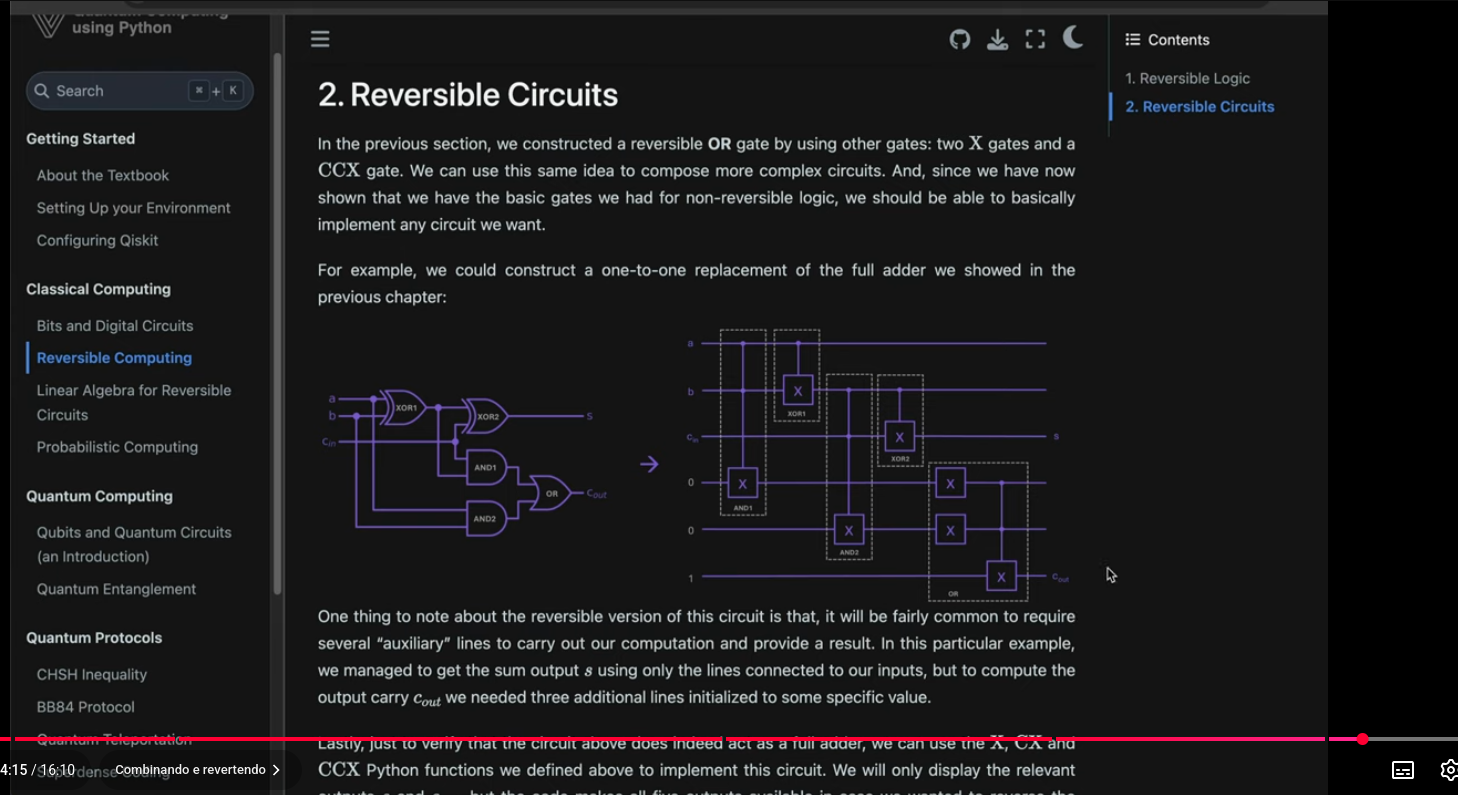

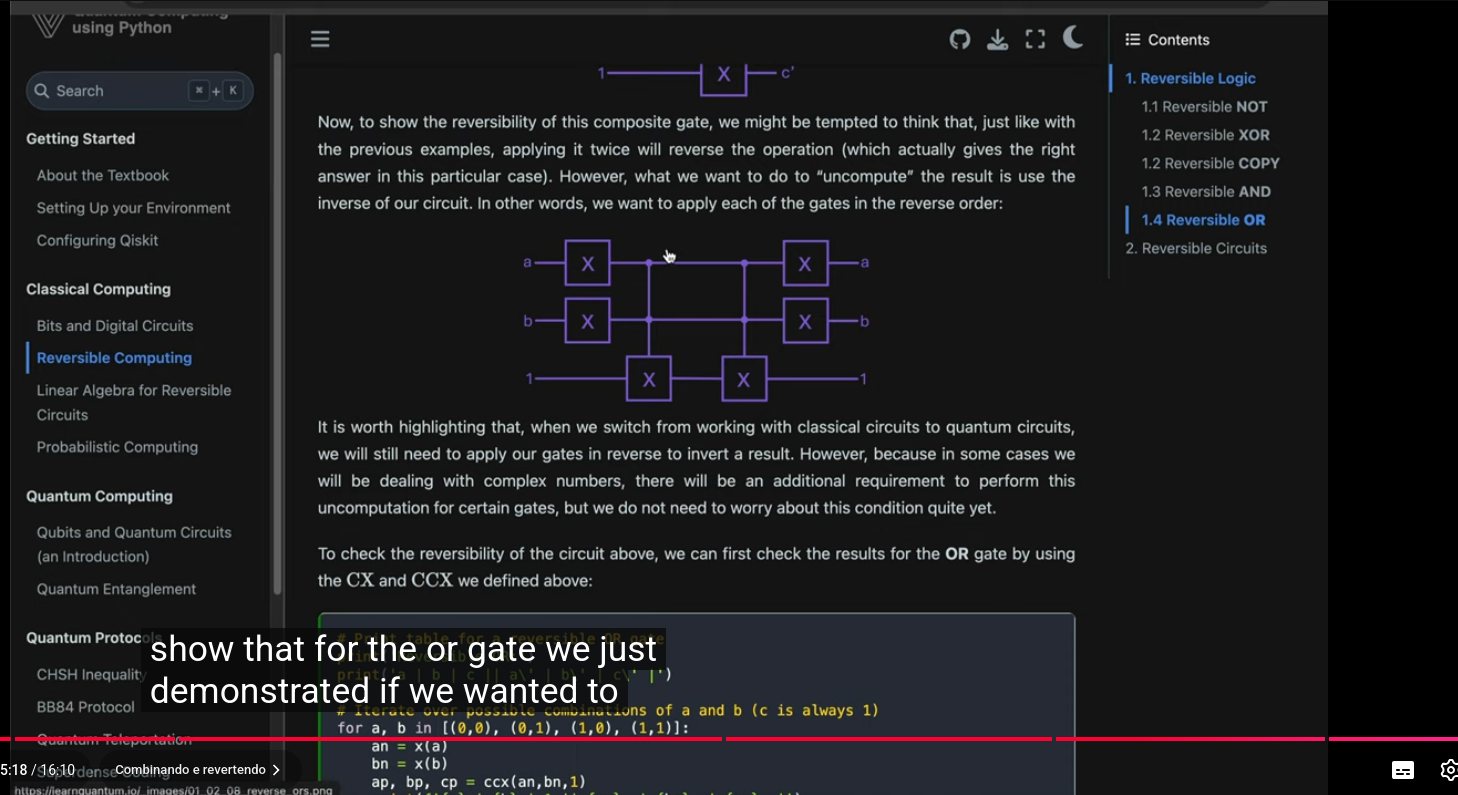

### 2. Reversible Circuits

https://learnquantum.io/chapters/01_classical_computing/01_02_reversible_computing.html

In [4]:
# define ccx gate as a function:
def ccx(a_in, b_in, c_in):
    
    # a' and b' are always equal to a and b.
    a_out = a_in                 
    b_out = b_in
    
    # if both controls are 1: negate target (c' = c̅), else: leave b alone (c' = c).
    if a_in == 1 and b_in == 1:                
        c_out = x(c_in)
    else:
        c_out = c_in

    return (a_out, b_out, c_out)

In [6]:
# define cx gate as a function:
def cx(a_in, b_in):
    
    # a' is always equal to a.
    a_out = a_in
    
    # if control is one (i.e., a == 1): negate target (b' = b̅), 
    # else: leave b alone (b' = b).
    if a_in == 1:                
        b_out = x(b_in)
    else:
        b_out = b_in

    return (a_out, b_out)

In [8]:
# define x gate as a function:
def x(a_in):
    a_out = a_in ^ 1   # Remember ^ performs the XOR operation. a^1 = a̅
    return a_out

In [9]:
# Print table for a reversible Full Adder
print('Reversible Full Adder')
print(f'a | b | cin || s | cout |')

# Iterate over possible combinations of a, b and cin
inputs = [(0,0,0), (0,0,1), (0,1,0), (0,1,1),
          (1,0,0), (1,0,1), (1,1,0), (1,1,1)]

for a, b, c in inputs:
    a1, b1, d1 = ccx(a, b, 0)      # AND1
    a2, b2 = cx(a1, b1)            # XOR1
    a3, c3, e3 = ccx(b2, c, 0)     # AND2
    b4, s = cx(b2, c3)             # XOR2
    
    d5 = x(d1)                     # OR ...
    e5 = x(e3)                     # 
    d6, e6, cout = ccx(d5, e5, 1)  #

    print(f'{a} | {b} | {c}   || {s} | {cout}    |')

Reversible Full Adder
a | b | cin || s | cout |
0 | 0 | 0   || 0 | 0    |
0 | 0 | 1   || 1 | 0    |
0 | 1 | 0   || 1 | 0    |
0 | 1 | 1   || 0 | 1    |
1 | 0 | 0   || 1 | 0    |
1 | 0 | 1   || 0 | 1    |
1 | 1 | 0   || 0 | 1    |
1 | 1 | 1   || 1 | 1    |


In [11]:
# Reversible Full Adder
# a | b | cin || s | cout |
# 0 | 0 | 0   || 0 | 0    |
# 0 | 0 | 1   || 1 | 0    |
# 0 | 1 | 0   || 1 | 0    |
# 0 | 1 | 1   || 0 | 1    |
# 1 | 0 | 0   || 1 | 0    |
# 1 | 0 | 1   || 0 | 1    |
# 1 | 1 | 0   || 0 | 1    |
# 1 | 1 | 1   || 1 | 1    |
# ctrl + : comenta em #